In [23]:
pwd

'/home/oliveoil/Desktop/VisionRobotics/dynamics/feasible-dynamics-estimation/Feas-Ident-WAM4'

In [20]:
datafolder = 'data/'
tmpfolder = 'tmp/'


from sympy import init_printing
init_printing()

%matplotlib inline
import sympybotics

In [3]:
# open the dataset and model it directly since it has already been preprocessed and is already the residual
# just get the residual to be 0
import pandas as pd
dof = 4

def set_q_dq_ddq_tau_residual(wam_name):
    wam_name = wam_name # or 'slax' or 'ares' or 'all'
    
    dataset_path_prefix = f'residual_data/{wam_name}_combined_datasets__joint_'
    dataset_filetype = '.dat'

    q=[]
    dq=[]
    ddq=[]
    tau_residual=[]
    
    for joint_i in range(dof):
        joint_i = str(joint_i)
        dataset_path = dataset_path_prefix + joint_i + dataset_filetype 
        
        df = pd.read_csv(dataset_path, usecols=['q','dq','ddq','tau_residual'])
        q_i = df['q'].to_numpy()
        dq_i = df['dq'].to_numpy()
        ddq_i = df['ddq'].to_numpy()
        
        tau_residual_i = df['tau_residual'].to_numpy()

        q.append(q_i)
        dq.append(dq_i)
        ddq.append(ddq_i)
        tau_residual.append(tau_residual_i)        
      
        df.plot()

    q=np.array(q)
    dq=np.array(dq)
    ddq=np.array(ddq)
    tau_residual=np.array(tau_residual)
    
    print(tau_residual.shape)
    print(q.shape)
    print(dq.shape)
    print(ddq.shape)

    return q, dq, ddq, tau_residual

In [4]:
import numpy as np
import sympy as sp
from sklearn.preprocessing import PolynomialFeatures

def generate_regressor(
    q,
    dq,
    ddq,
    basis_type=None,
    poly_deg=2,
    poly_in=None,
    trig_in=None,
    include_bias=False,
    custom_basis_function=None,
    symbols=None
):
    if basis_type is None:
        basis_type = []
    if custom_basis_function is None:
        custom_basis_function = []

    q = np.asarray(q)
    dq = np.asarray(dq)
    ddq = np.asarray(ddq)

    if q.ndim == 1:
        q = q[:, None]
    if dq.ndim == 1:
        dq = dq[:, None]
    if ddq.ndim == 1:
        ddq = ddq[:, None]

    N = q.shape[0]

    if poly_in is None:
        poly_in = (q, dq, ddq)
    if trig_in is None:
        trig_in = (q, dq, ddq)

    basis_populated = []

    for b in basis_type:
        if b == 'Coulomb':
            basis_populated.append(np.sign(dq))
        elif b == 'viscous':
            basis_populated.append(dq)
        elif b == 'poly':
            X_poly = np.concatenate(poly_in, axis=1)
            poly = PolynomialFeatures(degree=poly_deg, include_bias=False)
            basis_populated.append(poly.fit_transform(X_poly))
        elif b == 'trig':
            X_trig = np.concatenate(trig_in, axis=1)
            basis_populated.append(np.concatenate([np.sin(X_trig), np.cos(X_trig)], axis=1))
        else:
            raise ValueError(f"Unknown basis type: {b}")

    if custom_basis_function:
        if symbols is None:
            raise ValueError("symbols must be provided for custom basis")
    
        q_symbol, dq_symbol, ddq_symbol = symbols
    
        compiled_basis = [
            sp.lambdify((q_symbol, dq_symbol, ddq_symbol), expr, modules="numpy")
            for expr in custom_basis_function
        ]
    
        for f in compiled_basis:
            val = np.asarray(f(q, dq, ddq))
    
            if val.ndim == 0:
                val = np.full((N, 1), float(val))
            elif val.ndim == 1:
                val = val[:, None]
            elif val.ndim == 2 and val.shape[1] == 1:
                pass
            else:
                # raise ValueError(f"Invalid custom basis shape: {val.shape}")
                pass
    
            basis_populated.append(val)

    if include_bias:
        basis_populated.append(np.ones((N, 1)))

    Phi = np.concatenate(basis_populated, axis=1)
    return Phi

In [5]:
import numpy as np

def correlation_groups(C, thresh=0.995):
    """
    C: correlation matrix (n x n)
    returns: list of lists (each = indices of one correlated group)
    """
    n = C.shape[0]
    visited = np.zeros(n, dtype=bool)
    groups = []

    for i in range(n):
        if visited[i]:
            continue

        stack = [i]
        group = []

        while stack:
            j = stack.pop()
            if visited[j]:
                continue

            visited[j] = True
            group.append(j)

            # find neighbors strongly correlated with j
            neighbors = np.where(np.abs(C[j]) >= thresh)[0]

            for k in neighbors:
                if not visited[k]:
                    stack.append(k)

        groups.append(sorted(group))

    return groups

def groups_to_mask(groups, n):
    mask = np.zeros(n, dtype=bool)
    for g in groups:
        mask[g[0]] = True   # keep first
    return mask

def groups_to_mask_by_variance(groups, Phi):
    mask = np.zeros(Phi.shape[1], dtype=bool)

    for g in groups:
        stds = [np.std(Phi[:, j]) for j in g]
        keep = g[np.argmax(stds)]
        mask[keep] = True

    return mask

def correlation_prune_mask(Phi, thresh=0.995):
    # normalize (important)
    Phi = np.asarray(Phi, dtype=float)
    std = Phi.std(axis=0)
    std[std == 0] = 1.0
    Phi_n = Phi / std

    C = np.corrcoef(Phi_n, rowvar=False)

    groups = correlation_groups(C, thresh)

    mask = groups_to_mask_by_variance(groups, Phi)

    return mask, groups

In [6]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import itertools
# --------------------------
# helpers
# --------------------------

def generate_polynomial_basis(symbols, degree):
    # basis = [1]  # include bias
    basis=[]
    n = len(symbols)

    for deg in range(1, degree + 1):
        for combo in itertools.combinations_with_replacement(range(n), deg):
            term = 1
            for idx in combo:
                term *= symbols[idx]
            basis.append(term)

    return basis

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
    
def pick_elbow(lambda_vals, rmse_vals, nnz_vals):
    """
    Simple elbow heuristic:
    choose the point closest to the lower-left corner
    after normalizing complexity and error.
    """
    x = np.asarray(nnz_vals, dtype=float)
    y = np.asarray(rmse_vals, dtype=float)

    x_norm = (x - x.min()) / (x.max() - x.min() + 1e-12)
    y_norm = (y - y.min()) / (y.max() - y.min() + 1e-12)

    score = np.sqrt(x_norm**2 + y_norm**2)
    return np.argmin(score)


def activated_basis_from_weights(w, basis, tol=1e-10):
    return [term for wi, term in zip(w, basis) if abs(wi) > tol]


def stlsq(Phi, b, lam, n_iter=10):
    Phi = np.asarray(Phi, dtype=float)
    b = np.asarray(b).reshape(-1)

    Phi_scale = np.linalg.norm(Phi, axis=0)
    Phi_scale[Phi_scale < 1e-12] = 1.0
    Phi_n = Phi / Phi_scale

    b_scale = np.linalg.norm(b)
    if b_scale < 1e-12:
        b_scale = 1.0
    b_n = b / b_scale

    w, *_ = np.linalg.lstsq(Phi_n, b_n, rcond=None)
    w = w.reshape(-1)

    prev_active = None

    for _ in range(n_iter):
        active = np.abs(w) >= lam

        if not np.any(active):
            w[:] = 0.0
            break

        w_new = np.zeros_like(w)
        w_new[active], *_ = np.linalg.lstsq(Phi_n[:, active], b_n, rcond=None)
        w_new = w_new.reshape(-1)

        new_active = np.abs(w_new) >= lam
        if prev_active is not None and np.array_equal(new_active, prev_active):
            w = w_new
            break

        w = w_new
        prev_active = new_active

    return b_scale * w / Phi_scale

    
def single_joint_sindy(i, basis_in=None, symbols=None, normalize=True):
    if symbols is None:
        symbols = sp.symbols(('q_symbol', 'dq_symbol', 'ddq_symbol'))

    q_symbol, dq_symbol, ddq_symbol = symbols

    if basis_in is None:
        basis_in = [
            q_symbol,
            dq_symbol,
            ddq_symbol,
            sp.sign(dq_symbol),
            sp.sin(q_symbol),
            sp.sin(dq_symbol),
            sp.sin(ddq_symbol),
        ]

    # --------------------------
    # data
    # --------------------------
    b = tau_residual[i, :]
    q_i = q[i, :]
    dq_i = dq[i, :]
    ddq_i = ddq[i, :]

    Phi = generate_regressor(
        q_i, dq_i, ddq_i,
        custom_basis_function=basis_in,
        symbols=symbols
    )
    Phi = np.asarray(Phi, dtype=float)

    # --------------------------
    # diagnostics on raw Phi
    # --------------------------
    for k, expr in enumerate(basis_in):
        col = Phi[:, k]
        print(k, expr, "mean", np.mean(col), "std", np.std(col), "min", np.min(col), "max", np.max(col))

    # Avoid NaNs from constant columns in corrcoef
    nonconst = Phi.std(axis=0) > 1e-12
    if np.sum(nonconst) > 1:
        C = np.corrcoef(Phi[:, nonconst], rowvar=False)
        print(np.round(C, 3))

    # --------------------------
    # prune correlated columns
    # --------------------------
    mask_prune, groups = correlation_prune_mask(Phi, thresh=0.995)

    Phi = Phi[:, mask_prune]
    basis_in = [basis_in[j] for j in range(len(mask_prune)) if mask_prune[j]]

    print("Kept basis after pruning:")
    print(basis_in)
    print("###############################################")

    print("correlation diagnostics on pruned basis:")

    for k, expr in enumerate(basis_in):
        col = Phi[:, k]
        print(k, expr, "mean", np.mean(col), "std", np.std(col), "min", np.min(col), "max", np.max(col))

    # Avoid NaNs from constant columns in corrcoef
    nonconst = Phi.std(axis=0) > 1e-12
    if np.sum(nonconst) > 1:
        C = np.corrcoef(Phi[:, nonconst], rowvar=False)
        print(np.round(C, 3))

    # --------------------------

    # --------------------------
    # normalize pruned regressor
    # --------------------------
    # if normalize:
    #     # Use column norm or std. Norm is usually better for sparse regression.
    #     Phi_scale = np.linalg.norm(Phi, axis=0)
    #     Phi_scale[Phi_scale < 1e-12] = 1.0
    #     Phi_n = Phi / Phi_scale

    #     b_scale = np.linalg.norm(b)
    #     if b_scale < 1e-12:
    #         b_scale = 1.0
    #     b_n = b / b_scale
    # else:
    #     Phi_scale = np.ones(Phi.shape[1])
    #     b_scale = 1.0
    #     Phi_n = Phi
    #     b_n = b

    # # --------------------------
    # # dense least-squares on normalized system
    # # --------------------------
    # w_dense_n, *_ = np.linalg.lstsq(Phi_n, b_n, rcond=None)
    # w_dense_n = np.asarray(w_dense_n).reshape(-1)

    # # threshold on normalized weights
    # lambda_vals = np.linspace(0.0, np.max(np.abs(w_dense_n)), 50)

    rmse_vals = []
    nnz_vals = []
    weight_vectors = []
    active_basis_list = []
    b_hat_vals = []

    # --------------------------
    # threshold + refit on normalized system
    # --------------------------
    # for lam in lambda_vals:
    #     mask_active = np.abs(w_dense_n) >= lam

    #     if not np.any(mask_active):
    #         w_sparse_n = np.zeros_like(w_dense_n)
    #         w_sparse = np.zeros_like(w_dense_n)
    #         b_hat = np.zeros_like(b)
    #     else:
    #         # Phi_active_n = Phi_n[:, mask_active]
    #         # w_active_n, *_ = np.linalg.lstsq(Phi_active_n, b_n, rcond=None)

    #         # w_sparse_n = np.zeros_like(w_dense_n)
    #         # w_sparse_n[mask_active] = np.asarray(w_active_n).reshape(-1)

    #         # # Convert normalized coefficients back to physical scale
    #         # # b_n = Phi_n @ w_sparse_n
    #         # # b   = b_scale * (Phi / Phi_scale) @ w_sparse_n
    #         # #     = Phi @ (b_scale * w_sparse_n / Phi_scale)
            
    #         # w_sparse = b_scale * w_sparse_n / Phi_scale
    #         w_sparse = stlsq(Phi,b,lam)

    #         b_hat = Phi @ w_sparse

    #     b_hat_vals.append(b_hat)

    #     err = rmse(b, b_hat)
    #     rmse_vals.append(err)
    #     nnz_vals.append(np.count_nonzero(w_sparse))
    #     weight_vectors.append(w_sparse.copy())
    #     active_basis_list.append(activated_basis_from_weights(w_sparse, basis_in))

    lambda_vals = np.linspace(0.01, 0.8, 50)

    for lam in lambda_vals:
        w_sparse = stlsq(Phi, b, lam)
        b_hat = Phi @ w_sparse
    
        b_hat_vals.append(b_hat)
        err = rmse(b, b_hat)
        rmse_vals.append(err)
        nnz_vals.append(np.count_nonzero(np.abs(w_sparse) > 1e-10))
        weight_vectors.append(w_sparse.copy())
        active_basis_list.append(activated_basis_from_weights(w_sparse, basis_in, tol=1e-10))

    # --------------------------
    # print active symbolic basis
    # --------------------------
    for lam, w_sparse, active_terms, rmse_val in zip(lambda_vals, weight_vectors, active_basis_list, rmse_vals):
        print(f"lambda = {lam:.6f}")
        print("weights =", w_sparse)
        print("rmse =", rmse_val)
        print("active basis =", active_terms if active_terms else ["<none>"])
        print()

    # --------------------------
    # pick elbow
    # --------------------------
    best_idx = pick_elbow(lambda_vals, rmse_vals, nnz_vals)

    print("Chosen elbow point")
    print("lambda:", lambda_vals[best_idx])
    print("RMSE:", rmse_vals[best_idx])
    print("nonzero terms:", nnz_vals[best_idx])
    print("active basis:", active_basis_list[best_idx])
    print("weights:", weight_vectors[best_idx])

    return weight_vectors[best_idx], b_hat_vals[best_idx], active_basis_list[best_idx], lambda_vals[best_idx]

In [8]:
cd Feas-Ident-WAM4/

/home/oliveoil/Desktop/VisionRobotics/dynamics/feasible-dynamics-estimation/Feas-Ident-WAM4


[sin(q_symbol), sin(dq_symbol), sin(ddq_symbol), cos(q_symbol), cos(dq_symbol), cos(ddq_symbol), sign(q_symbol), sign(dq_symbol), sign(ddq_symbol), atan(q_symbol), atan(dq_symbol), atan(ddq_symbol), q_symbol, dq_symbol, ddq_symbol, q_symbol**2, dq_symbol*q_symbol, ddq_symbol*q_symbol, dq_symbol**2, ddq_symbol*dq_symbol, ddq_symbol**2]
(4, 21657)
(4, 21657)
(4, 21657)
(4, 21657)
(4, 21657)
(4, 21657)
(4, 21657)
(4, 21657)
0 sin(q_symbol) mean -0.5142302284294691 std 0.6222439085382321 min -0.9999999999864384 max 0.9239503231809365
1 sin(dq_symbol) mean -0.0033443337890989968 std 0.6037256717099573 min -0.9999989198966738 max 0.9999999986158884
2 sin(ddq_symbol) mean 0.05099861898701104 std 0.6304671176757309 min -0.9999999744564043 max 0.999999920155643
3 cos(q_symbol) mean 0.4269474882422641 std 0.4075483195156891 min -0.5576702073832402 max 0.9999999879125981
4 cos(dq_symbol) mean 0.7307677473093934 std 0.3185633818288323 min -0.22120065077647127 max 0.9999999999272333
5 cos(ddq_symbo

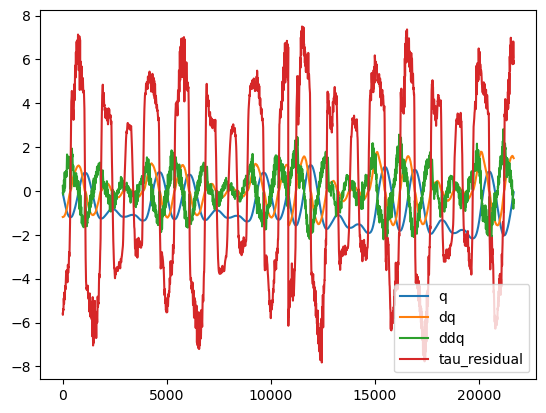

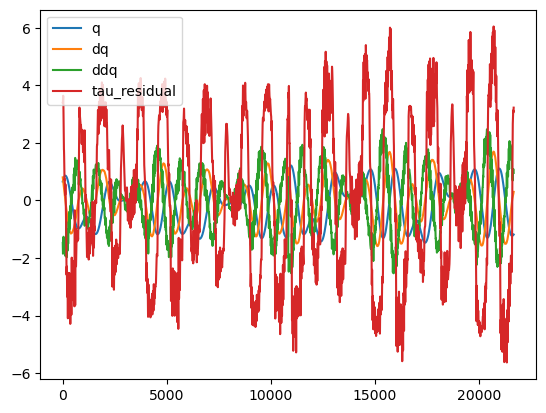

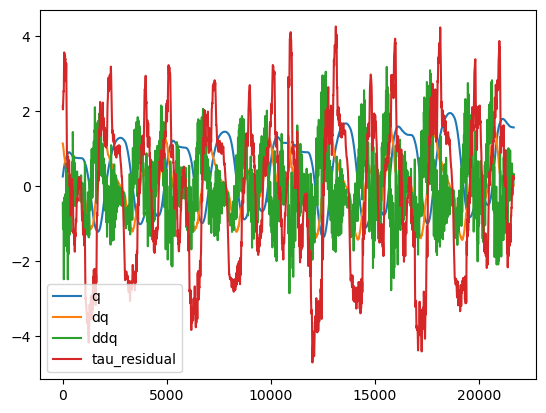

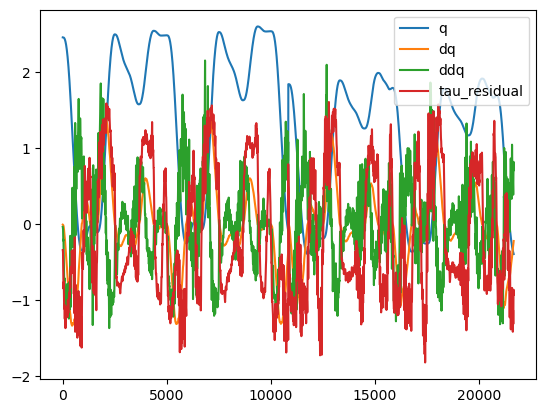

In [15]:

symbols = sp.symbols(('q_symbol', 'dq_symbol', 'ddq_symbol'))
symbols = [s for s in symbols]
z=2
poly_symbols = generate_polynomial_basis(symbols, degree=2)
# sin_symbols = [sp.sin(s) for s in symbols]
# cos_symbols = [sp.cos(s) for s in symbols]
sin_symbols=[]
cos_symbols=[]
for i in range(1,z):
    sin_symbols+=[sp.sin(i*s) for s in symbols]
    cos_symbols+=[sp.cos(i*s) for s in symbols]
sign_symbols = [sp.sign(s) for s in symbols]
arctan_symbols = [sp.atan(s) for s in symbols]
# basis_in = poly_symbols+arctan_symbols+sin_symbols+cos_symbols
# basis_in = poly_symbols+arctan_symbols
# basis_in= cos_symbols + poly_symbols + sign_symbols
basis_in = sin_symbols + cos_symbols + sign_symbols + arctan_symbols + poly_symbols 

print(basis_in)


q, dq, ddq, tau_residual = set_q_dq_ddq_tau_residual('zeus')
print(q.shape)
print(dq.shape)
print(ddq.shape)
print(tau_residual.shape)

w_vects = [] 
b_vects=[]
activateds=[]
basis_in_i_list = []
lam_vals = []

for i in range(dof):
    basis_in_i = basis_in.copy()
    w, b, active_basis, lambda_val = single_joint_sindy(i, basis_in_i, symbols)
    w_vects.append(w.tolist())
    b_vects.append(b.tolist())
    basis_in_i_list.append(basis_in_i)
    lam_vals.append(lambda_val)
    activateds.append(active_basis)
    
                                 
tau_residual_prediction = np.array(b_vects)

In [16]:
print(tau_residual_prediction.shape)
print(tau_residual.shape)

(4, 21657)
(4, 21657)


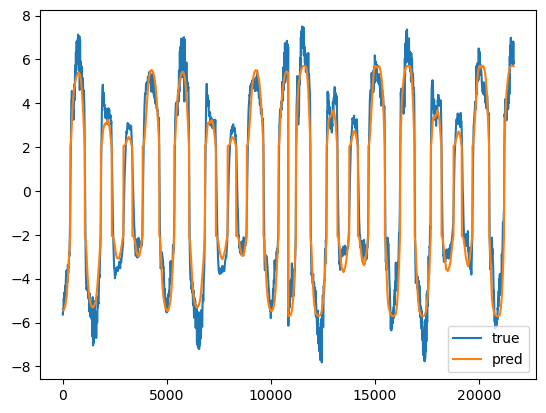

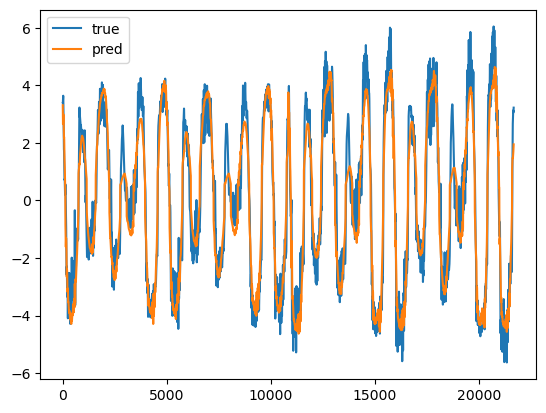

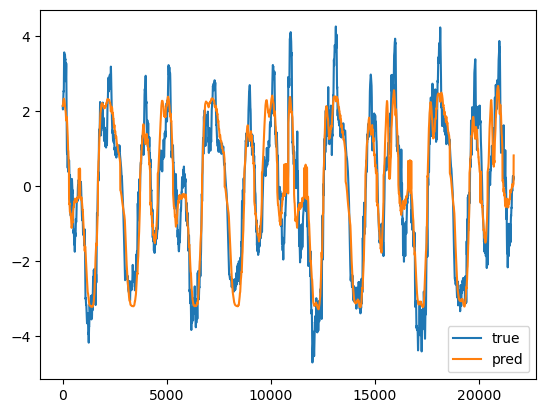

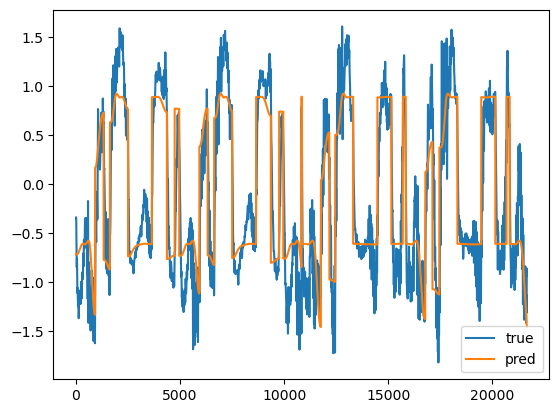

In [17]:
import matplotlib.pyplot as plt
# tau_residual = tau_residual.reshape(-1, dof)
# tau_residual_prediction = tau_residual_prediction.reshape(-1,dof)

for i in range(dof):
    plt.plot(tau_residual[i, :], label='true')
    plt.plot(tau_residual_prediction[i, :], label='pred')
    plt.legend()
    plt.show()

In [18]:
tau_residual = tau_residual.reshape(-1, dof)
tau_residual_prediction = tau_residual_prediction.reshape(-1,dof)

print(tau_residual.shape)
print(tau_residual_prediction.shape)

rmse_vals = []

for i in range(dof):
    rmse_vals.append(rmse(tau_residual[:,i], tau_residual_prediction[:,i]))

(21657, 4)
(21657, 4)


In [19]:

print(f"Full basis library used in sparse functional regression:\n")

print(basis_in)
print("--------\n")

for i in range(len(activateds)):
    print(f" ###### Joint {i} activated basis: #####")
    print(activateds[i])
    print(f" ## lambda value: ")
    print(lam_vals[i])
    print(f" ## Associated weights for the basis: ##")
    print(w_vects[i])
    print(f" ## RMSE between true and predicted residual:")
    print(rmse_vals[i])

Full basis library used in sparse functional regression:

[sin(q_symbol), sin(dq_symbol), sin(ddq_symbol), cos(q_symbol), cos(dq_symbol), cos(ddq_symbol), sign(q_symbol), sign(dq_symbol), sign(ddq_symbol), atan(q_symbol), atan(dq_symbol), atan(ddq_symbol), q_symbol, dq_symbol, ddq_symbol, q_symbol**2, dq_symbol*q_symbol, ddq_symbol*q_symbol, dq_symbol**2, ddq_symbol*dq_symbol, ddq_symbol**2]
--------

 ###### Joint 0 activated basis: #####
[sin(dq_symbol), sign(dq_symbol)]
 ## lambda value: 
0.12285714285714285
 ## Associated weights for the basis: ##
[0.0, 3.657118977639564, 0.0, 0.0, 0.0, 0.0, 2.048383713497254, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 ## RMSE between true and predicted residual:
0.7839320623578154
 ###### Joint 1 activated basis: #####
[sin(dq_symbol), sin(ddq_symbol), sign(dq_symbol), atan(ddq_symbol), dq_symbol, q_symbol**2, dq_symbol*q_symbol, ddq_symbol*dq_symbol, ddq_symbol**2]
 ## lambda value: 
0.09061224489795917
 ## Associated weights fo